# Statistical Modelling — ARIMA, Holt-Winters, and Prophet
### Goal: Model unit_sales using three different forecasting approaches on a feature-rich dataset

---

This notebook uses the expanded feature-engineered dataset built in the Feature Engineering notebook.  
It covers three models side by side so you can understand how each one works, what features it needs, and how to evaluate them on the same data.

### What is in the dataset?

The dataset contains **452 days** of daily unit sales (January 2013 – March 2014) along with 24 features:

| Feature group | Columns |
|---|---|
| **Target** | `unit_sales` |
| **External signal** | `dcoilwtico` (crude oil price) |
| **Holiday flags** | `is_national_holiday`, `is_regional_holiday`, `is_local_holiday` |
| **Calendar** | `year`, `month`, `day`, `dayofweek`, `quarter`, `week_of_year`, `is_weekend`, `is_month_start`, `is_month_end` |
| **Lag features** | `lag_1`, `lag_7`, `lag_14`, `lag_30` |
| **Rolling features** | `rolling_7d_mean`, `rolling_14d_mean`, `rolling_30d_mean`, `rolling_7d_std` |
| **Oil lags** | `oil_lag_1`, `oil_rolling_7d_mean` |

### The three models

| Model | Type | What it uses from the dataset |
|---|---|---|
| **ARIMA / SARIMAX** | Statistical | Target series + external regressors (oil, holidays) |
| **Holt-Winters** | Statistical | Target series only — no external features |
| **Prophet** | Bayesian curve-fitting | Target series + holiday flags + regressors |

### Notebook structure

1. Install and import libraries
2. Load and prepare the dataset
3. Explore the data and feature importance
4. Train / test split
5. **ARIMA / SARIMAX** — preparation, features, factors, evaluation
6. **Holt-Winters** — preparation, features, factors, evaluation
7. **Prophet** — preparation, features, factors, evaluation
8. Model performance comparison

---
## Step 1 — Install Libraries

---
## Step 2 — Import Libraries

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statsmodels — ARIMA and Holt-Winters
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Prophet
from prophet import Prophet

# Scikit-learn — feature importance and evaluation metrics
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 3 — Load the Dataset

We load the feature-engineered CSV that was built in the Feature Engineering notebook.  
If you ran the Feature Engineering notebook in this session, you can also retrieve it with:
```python
%store -r df
```
Otherwise, load it from the CSV file below.

In [9]:
# Path to the feature-engineered dataset
DATA_DIR = "/home/ana/cosas_eukene/accounts/github/time_series_analysis_ona/outputs"
FILE_NAME = "timeseries_with_features.csv"

file_path = os.path.join(DATA_DIR, FILE_NAME)

# Check that the file exists before loading
print("File path:", file_path)
print("File exists:", os.path.exists(file_path))

# Load dataset
df = pd.read_csv(file_path)

# Prepare data
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# Basic checks
print("\nDataset loaded successfully!")
print("Shape:", df.shape)
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())

df.head()

File path: /home/ana/cosas_eukene/accounts/github/time_series_analysis_ona/outputs/timeseries_with_features.csv
File exists: True

Dataset loaded successfully!
Shape: (424, 31)
Date range: 2013-02-01 to 2014-03-31


,date,unit_sales,day_of_week,day_number,month,year,is_weekend,rolling_7d,zscore,is_outlier,...,lag_7,lag_14,lag_30,rolling_7d_mean,rolling_14d_mean,rolling_30d_mean,rolling_7d_std,oil_lag_1,oil_lag_7,oil_rolling_7d_mean
0,2013-02-01,401.0,Friday,4,2,2013,0,456.285714,-0.444388,False,...,389.0,60.0,582.0,454.571429,497.071429,520.833333,154.059358,97.65,95.15,96.378571
1,2013-02-02,775.0,Saturday,5,2,2013,1,467.428571,1.714749,False,...,697.0,667.0,310.0,456.285714,521.428571,514.800000,153.272866,97.46,95.15,96.708571
2,2013-02-03,855.0,Sunday,6,2,2013,1,501.571429,2.176596,False,...,616.0,1090.0,338.0,467.428571,529.142857,530.300000,174.986530,97.46,95.15,97.038571
3,2013-02-04,411.0,Monday,0,2,2013,0,514.857143,-0.386657,False,...,318.0,760.0,654.0,501.571429,512.357143,547.533333,224.981375,97.46,95.95,97.368571
4,2013-02-05,272.0,Tuesday,1,2,2013,0,497.571429,-1.189117,False,...,393.0,461.0,979.0,514.857143,487.428571,539.433333,214.852219,96.21,97.62,97.405714


In [10]:
# Preview the data

print("First few rows of the dataframe:")
print(df.head())                                   # View the first few rows of the dataframe      
print("Missing values in the dataframe:")
print(df.isnull().sum()[df.isnull().sum() > 0])    # Check for missing values in the dataframe

First few rows of the dataframe:
        date  unit_sales day_of_week  day_number  month  year  is_weekend  \
0 2013-02-01       401.0      Friday           4      2  2013           0   
1 2013-02-02       775.0    Saturday           5      2  2013           1   
2 2013-02-03       855.0      Sunday           6      2  2013           1   
3 2013-02-04       411.0      Monday           0      2  2013           0   
4 2013-02-05       272.0     Tuesday           1      2  2013           0   

   rolling_7d    zscore  is_outlier  ...  lag_7  lag_14  lag_30  \
0  456.285714 -0.444388       False  ...  389.0    60.0   582.0   
1  467.428571  1.714749       False  ...  697.0   667.0   310.0   
2  501.571429  2.176596       False  ...  616.0  1090.0   338.0   
3  514.857143 -0.386657       False  ...  318.0   760.0   654.0   
4  497.571429 -1.189117       False  ...  393.0   461.0   979.0   

   rolling_7d_mean  rolling_14d_mean  rolling_30d_mean  rolling_7d_std  \
0       454.571429        4

---
## Step 4 — Explore the Data

Before modelling, we need to understand the data visually and statistically.  
This section covers:
- The overall shape of unit_sales over time
- The distribution of sales values
- Which features are most correlated with unit_sales
- Whether the series is stationary (required for ARIMA)

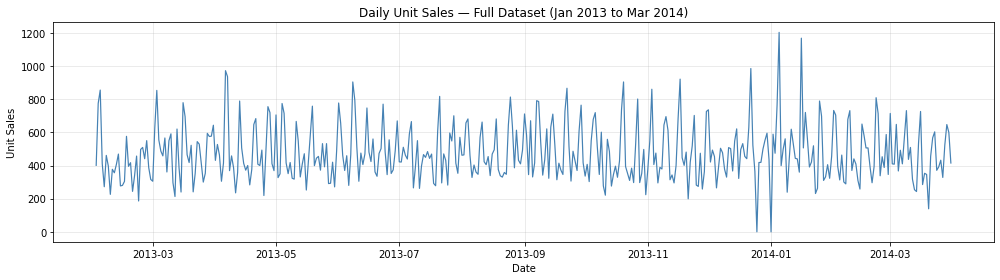

In [12]:
# Plot unit_sales over time
plt.figure(figsize=(14, 4))
plt.plot(df['date'], df['unit_sales'], color='steelblue', linewidth=1.2)
plt.title('Daily Unit Sales — Full Dataset (Jan 2013 to Mar 2014)')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# What to look for:
# - Is there an upward or downward trend?
# - Are there repeating weekly patterns?
# - Are there unusual spikes (likely holidays or weekends)?

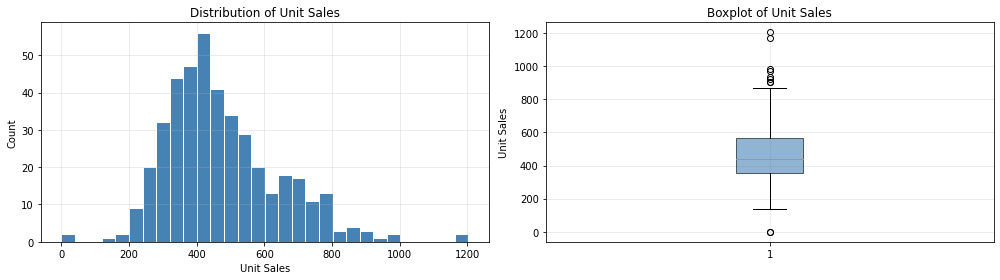

Unit Sales summary:
count     424.00
mean      474.94
std       167.93
min         0.00
25%       357.50
50%       441.00
75%       566.25
max      1203.00
Name: unit_sales, dtype: float64


In [13]:
# Plot the distribution of unit_sales
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df['unit_sales'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Unit Sales')
axes[0].set_xlabel('Unit Sales')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

# Box plot to see spread and outliers
axes[1].boxplot(df['unit_sales'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot of Unit Sales')
axes[1].set_ylabel('Unit Sales')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Unit Sales summary:")
print(df['unit_sales'].describe().round(2))

The distribution of unit sales is slightly right-skewed, with most values concentrated between 300 and 600 units. 

The boxplot reveals several high-value outliers, indicating occasional spikes in sales, as well as a few very low values. 

This suggests that the time series contains significant variability and irregular extreme values, which may make accurate forecasting more challenging.

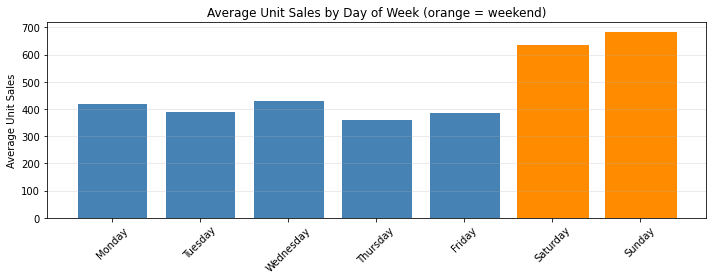

In [15]:
# Order the days correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

avg_by_day = df.groupby('day_of_week')['unit_sales'].mean().reindex(day_order)

plt.figure(figsize=(10, 4))
bars = plt.bar(avg_by_day.index, avg_by_day.values, color='steelblue', edgecolor='white')

# Highlight weekends
for i, day in enumerate(avg_by_day.index):
    if day in ['Saturday', 'Sunday']:
        bars[i].set_color('darkorange')

plt.title('Average Unit Sales by Day of Week (orange = weekend)')
plt.ylabel('Average Unit Sales')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

The average unit sales vary significantly across the days of the week. 

Sales are noticeably higher during weekends, especially on Saturday and Sunday, compared to weekdays. This confirms the presence of strong weekly seasonality in the data.

As a result, capturing weekly patterns will be important for building accurate forecasting models.

---
## Step 5 — Feature Importance

Before choosing which features to give each model, we measure how much each feature  
contributes to predicting unit_sales.

We use two approaches:

**1. Correlation** — measures the linear relationship between each feature and unit_sales.  
Simple and fast, but only captures straight-line relationships.

**2. Random Forest Feature Importance** — measures how much each feature reduces  
prediction error across many decision trees.  
More powerful — captures non-linear relationships too.

> Note: Feature importance tells us which features are informative.  
> But each model has its own rules about which types of features it can actually accept.  
> We will apply those rules in each model's section.

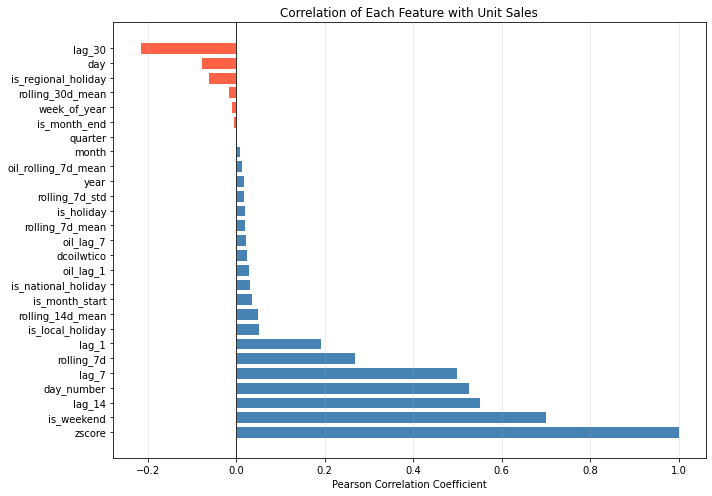

In [16]:
# Correlation with unit_sales (Linear relationship)
# When this feature goes up, does unit_sales tend to go up or down in a straight-line pattern?

# Drop rows with NaN (from lag/rolling features) before calculating correlation
df_clean = df.dropna().reset_index(drop=True)

numeric_cols = df_clean.select_dtypes(include='number').columns.tolist()
numeric_cols.remove('unit_sales')   # remove target from features list

correlations = df_clean[numeric_cols].corrwith(df_clean['unit_sales'])
correlations = correlations.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 7))
colors = ['steelblue' if v >= 0 else 'tomato' for v in correlations.values]
plt.barh(correlations.index, correlations.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Each Feature with Unit Sales')
plt.xlabel('Pearson Correlation Coefficient')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

Lag features (lag_1, lag_7, lag_14) show the strongest correlation with unit sales, confirming strong temporal dependency.

The is_weekend feature also shows relevant correlation, suggesting weekly seasonality.

Rolling features have moderate correlation, capturing local trends.

Some features like zscore may introduce data leakage and should be used carefully.

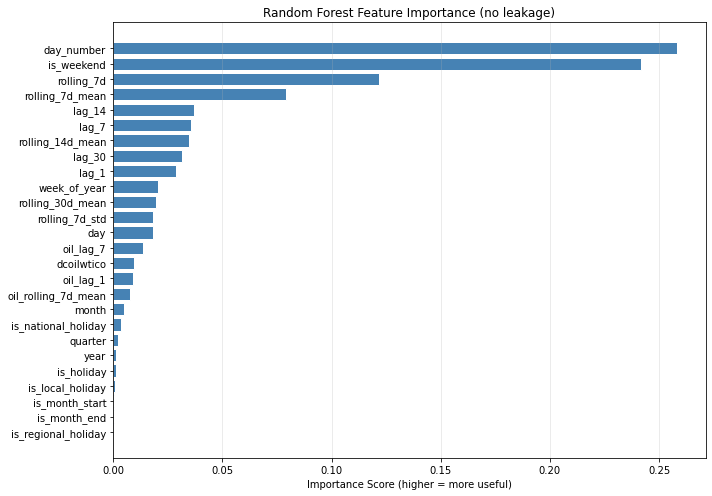

In [18]:
# Random Forest Feature (Non-linear relationships)
# Which feature reduces prediction error the most?

# --- Prepare data ---
X = df_clean[numeric_cols].drop(columns=["unit_sales", "zscore"], errors="ignore")
y = df_clean["unit_sales"]

# --- Train model ---
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)

# --- Get importance scores ---
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True)

# --- Plot ---
plt.figure(figsize=(10, 7))
plt.barh(importance.index, importance.values, color='steelblue', edgecolor='white')
plt.title('Random Forest Feature Importance (no leakage)')
plt.xlabel('Importance Score (higher = more useful)')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

After removing features that could introduce data leakage, the Random Forest results show that calendar-related variables such as day_number and is_weekend are the most important predictors of unit sales.

This confirms the strong influence of weekly patterns and temporal structure in the data.

Lag and rolling features also contribute to the model, capturing temporal dependencies and short-term trends.

In [20]:
# --- Correlation (clean) ---
correlations = df_clean[numeric_cols].corrwith(df_clean['unit_sales'])
correlations = correlations.drop(labels=["unit_sales", "zscore"], errors="ignore")

# --- RF importance already clean ---
rf_importance = importance.sort_values(ascending=False)

# --- Combine ---
importance_df = pd.DataFrame({
    'Correlation with unit_sales': correlations.round(3),
    'RF Importance': rf_importance.round(4)
})

print("Feature Importance Summary:")
print()
print(importance_df.sort_values('RF Importance', ascending=False).to_string())

Feature Importance Summary:

                     Correlation with unit_sales  RF Importance
day_number                                 0.525         0.2584
is_weekend                                 0.701         0.2418
rolling_7d                                 0.268         0.1218
rolling_7d_mean                            0.021         0.0791
lag_14                                     0.551         0.0372
lag_7                                      0.498         0.0355
rolling_14d_mean                           0.050         0.0346
lag_30                                    -0.217         0.0316
lag_1                                      0.192         0.0286
week_of_year                              -0.011         0.0207
rolling_30d_mean                          -0.020         0.0194
rolling_7d_std                             0.018         0.0184
day                                       -0.079         0.0181
oil_lag_7                                  0.022         0.0138
dcoilwtico 

The feature importance results show that day_number and is_weekend are among the most important predictors in the Random Forest model.

This suggests that calendar structure and weekend effects have a strong influence on unit sales.

Lag features such as lag_7 and lag_14 also show relatively strong correlation, which confirms that the series has clear temporal dependency and weekly patterns.

In contrast, oil and holiday-related variables seem to have a much smaller impact in this analysis.

## Step 6 — Train / Test Split

We split the data into training and test sets **by time** — never randomly.  
The model must always train on older data and be tested on newer data it has never seen.

We use the **last 89 days** as the test set.  
This provides almost 3 months of unseen data to evaluate each model.

In [23]:
# -------------------------------
# Step 6 — Train / Test Split
# -------------------------------

TEST_SIZE = 89  # last ~3 months

train = df.iloc[:-TEST_SIZE].copy()
test  = df.iloc[-TEST_SIZE:].copy()

# Drop NaNs ONLY in training (important for lag features)
train_clean = train.dropna().reset_index(drop=True)

print("Training set:", len(train), "days (", len(train_clean), "after dropping NaNs)")
print("  From:", train['date'].min().date(), "to", train['date'].max().date())

print("\nTest set:", len(test), "days")
print("  From:", test['date'].min().date(), "to", test['date'].max().date())

Training set: 335 days ( 335 after dropping NaNs)
  From: 2013-02-01 to 2014-01-01

Test set: 89 days
  From: 2014-01-02 to 2014-03-31


The dataset is split using a time-based approach.

The last 89 days are used as the test set, and the rest for training.

This ensures the model is evaluated on future unseen data.

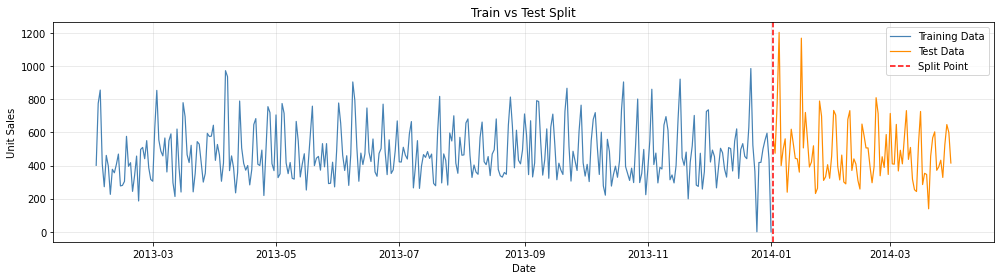

In [25]:
# Visualise the split

plt.figure(figsize=(14, 4))
plt.plot(train['date'], train['unit_sales'], label='Training Data', color='steelblue', linewidth=1.2)
plt.plot(test['date'],  test['unit_sales'],  label='Test Data',     color='darkorange', linewidth=1.2)
plt.axvline(x=test['date'].min(), color='red', linestyle='--', linewidth=1.5, label='Split Point')
plt.title('Train vs Test Split')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The dataset is split into training and test sets using a time-based split.  
The vertical line marks the point where the model stops training and starts forecasting future values.

---
## Model 1 — ARIMA / SARIMAX

### What is ARIMA?

ARIMA stands for **AutoRegressive Integrated Moving Average**.  
It forecasts a series using three mechanisms:

| Component | Parameter | What it does |
|---|---|---|
| **AR** — AutoRegressive | p | Uses past values of the series to predict the future |
| **I** — Integrated | d | Differences the series to remove trend and make it stationary |
| **MA** — Moving Average | q | Uses past forecast errors to correct predictions |

**SARIMAX** extends ARIMA in two directions:
- **S** adds seasonal versions of p, d, q at a given period (e.g. every 7 days)
- **X** allows external regressors — extra input columns like oil price or holiday flags

### Which features does ARIMA/SARIMAX use?

| Feature type | Can ARIMA use it? | How |
|---|---|---|
| The target series (unit_sales) | Yes — required | Endogenous variable |
| Oil price, holiday flags | Yes | As exogenous regressors (the X in SARIMAX) |
| Lag features (lag_1, lag_7...) | No | ARIMA computes its own internal lags via the p parameter |
| Rolling averages | No | ARIMA handles smoothing internally |
| Calendar features (month, day) | Indirectly | Only if added as exogenous regressors |

> **Key rule:** Do not pass lag or rolling features as regressors to ARIMA.  
> These overlap with what ARIMA already does internally and can cause errors.

### Step 7 — Check Stationarity

In [26]:
# ARIMA requires the series to be stationary (no trend, stable variance)
# We use the Augmented Dickey-Fuller (ADF) test to check this

def check_stationarity(series, name):
    result = adfuller(series.dropna())
    p_value = result[1]
    print("ADF Test —", name)
    print("  p-value:", round(p_value, 4))
    if p_value <= 0.05:
        print("  Result: Stationary — ready for ARIMA")
    else:
        print("  Result: NOT stationary — differencing needed (set d > 0)")
    print()

# Test the raw unit_sales series
check_stationarity(train['unit_sales'], 'unit_sales (original)')

ADF Test — unit_sales (original)
  p-value: 0.0
  Result: Stationary — ready for ARIMA



The Augmented Dickey-Fuller test indicates that the series is stationary (p-value < 0.05).

This suggests that no differencing is required, and the ARIMA model can be used with d = 0.

However, visual inspection shows variability and possible seasonality, so model performance will still depend on capturing these patterns.

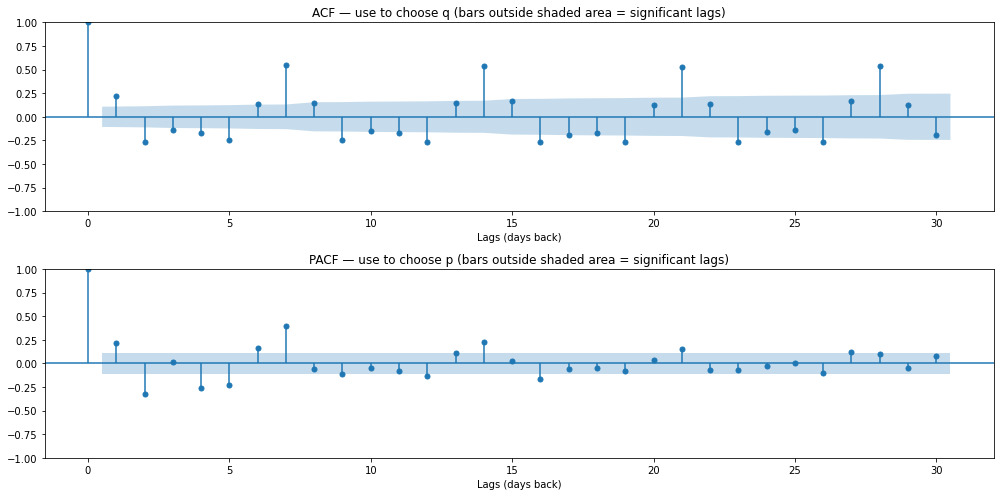

How to read these plots:
  PACF: count significant bars at lag 1, 2, 3... before they drop into the shaded zone → this is p
  ACF:  count significant bars at lag 1, 2, 3... before they drop into the shaded zone → this is q
  A spike at lag 7 in either plot → weekly seasonality → consider seasonal ARIMA (S parameter)


In [27]:
# Plot ACF and PACF to choose p and q parameters
# ACF  → helps choose q (Moving Average order)
# PACF → helps choose p (AutoRegressive order)

series = train['unit_sales'].dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

plot_acf(series, lags=30, ax=axes[0])
axes[0].set_title('ACF — use to choose q (bars outside shaded area = significant lags)')
axes[0].set_xlabel('Lags (days back)')

plot_pacf(series, lags=30, ax=axes[1])
axes[1].set_title('PACF — use to choose p (bars outside shaded area = significant lags)')
axes[1].set_xlabel('Lags (days back)')

plt.tight_layout()
plt.show()

print("How to read these plots:")
print("  PACF: count significant bars at lag 1, 2, 3... before they drop into the shaded zone → this is p")
print("  ACF:  count significant bars at lag 1, 2, 3... before they drop into the shaded zone → this is q")
print("  A spike at lag 7 in either plot → weekly seasonality → consider seasonal ARIMA (S parameter)")

How to read these plots:
- PACF: count significant bars at lag 1, 2, 3... before they drop into the shaded zone → this is p
- ACF:  count significant bars at lag 1, 2, 3... before they drop into the shaded zone → this is q
- A spike at lag 7 in either plot → weekly seasonality → consider seasonal ARIMA (S parameter)

In this case, both ACF and PACF show clear spikes at lag 7 and its multiples, indicating strong weekly seasonality.

The PACF suggests a small autoregressive component (p ≈ 1), and the ACF suggests a small moving average component (q ≈ 1).

Therefore, a reasonable configuration is:
- p = 1
- d = 0 (based on the stationarity test)
- q = 1
- seasonal period s = 7

### Step 8 — Prepare Exogenous Features for SARIMAX

In [29]:
# SARIMAX accepts external columns as exogenous regressors.
# These variables are known for both the training and test periods.

exog_cols = [
    "dcoilwtico",
    "is_national_holiday",
    "is_regional_holiday",
    "is_local_holiday",
    "is_weekend"
]

# Keep exogenous features aligned with train and test sets
exog_train = train[exog_cols].copy()
exog_test = test[exog_cols].copy()

print("Exogenous features selected for SARIMAX:")
for col in exog_cols:
    print(" ", col)

print("\nTraining exog shape:", exog_train.shape)
print("Test exog shape:    ", exog_test.shape)

display(exog_train.head())

Exogenous features selected for SARIMAX:
  dcoilwtico
  is_national_holiday
  is_regional_holiday
  is_local_holiday
  is_weekend

Training exog shape: (335, 5)
Test exog shape:     (89, 5)


,dcoilwtico,is_national_holiday,is_regional_holiday,is_local_holiday,is_weekend
0,97.46,0,0,0,0
1,97.46,0,0,0,1
2,97.46,0,0,0,1
3,96.21,0,0,0,0
4,96.68,0,0,0,0


### Step 9 — Factors That Influence SARIMAX Performance

Before fitting the model, it is useful to understand the key factors that affect SARIMAX performance:

| Factor | Effect |
|---|---|
| **p (AR order)** | Number of past values used for prediction |
| **d (differencing)** | Controls stationarity (0 if already stationary) |
| **q (MA order)** | Uses past forecast errors |
| **Seasonal order (P,D,Q,s)** | Captures repeating patterns (e.g. weekly seasonality) |
| **Exogenous regressors** | External variables (oil, holidays, weekends) that help explain variation |
| **Stationarity** | Required for stable and reliable estimates |

### Step 10 — Fit the SARIMAX Model

In [31]:
# We fit SARIMAX with:
# order=(1, 0, 1)              → AR=1, no differencing, MA=1
# seasonal_order=(1, 0, 0, 7)  → weekly seasonal AR component, period=7 days

print("Fitting SARIMAX model...")
print("  order=(1, 0, 1)")
print("  seasonal_order=(1, 0, 0, 7) — weekly seasonality")
print("  exog: oil price + holiday flags + weekend flag")
print()

sarimax_model = SARIMAX(
    train["unit_sales"],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 0, 7),
    exog=exog_train,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)

print("SARIMAX model fitted successfully!")
print("AIC:", round(sarimax_fit.aic, 2))
print("BIC:", round(sarimax_fit.bic, 2))

Fitting SARIMAX model...
  order=(1, 0, 1)
  seasonal_order=(1, 0, 0, 7) — weekly seasonality
  exog: oil price + holiday flags + weekend flag

SARIMAX model fitted successfully!
AIC: 4033.39
BIC: 4067.5


The SARIMAX model was fitted successfully.

AIC and BIC are information criteria used to evaluate model fit, where lower values indicate a better balance between model accuracy and complexity.

### Step 11 — SARIMAX Forecast and Evaluation

In [33]:
# Generate forecasts for the test period using SARIMAX

sarimax_preds = sarimax_fit.forecast(
    steps=len(test),
    exog=exog_test
)

# Clip negative predictions (sales cannot be negative)
sarimax_preds = sarimax_preds.clip(lower=0)

print("Forecast generated for", len(test), "days.")
print()
print("First 5 predictions:")
print(sarimax_preds.head().round(2))

Forecast generated for 89 days.

First 5 predictions:
335    373.81
336    372.68
337    605.74
338    613.52
339    396.33
Name: predicted_mean, dtype: float64


In [35]:
# Align predictions with test dates

sarimax_preds = pd.Series(
    sarimax_preds.values,
    index=test["date"]
)

print(sarimax_preds.head().round(2))

date
2014-01-02    373.81
2014-01-03    372.68
2014-01-04    605.74
2014-01-05    613.52
2014-01-06    396.33
dtype: float64


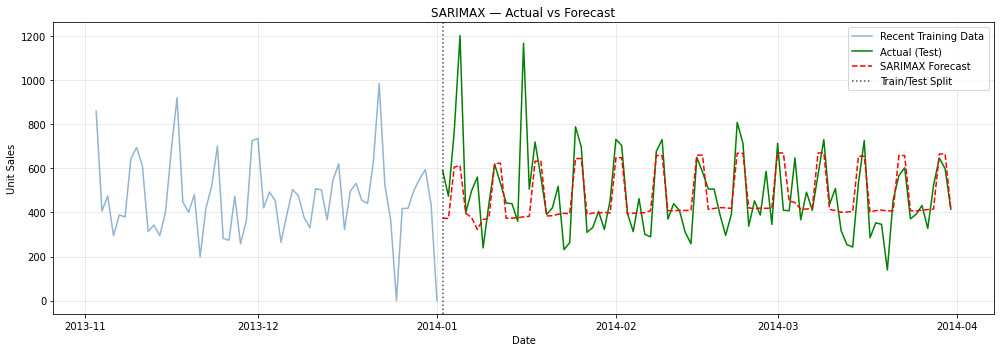

In [38]:
# Plot actual vs predicted values

plt.figure(figsize=(14, 5))

# Last 60 days of training data (context)
plt.plot(
    train["date"].iloc[-60:], 
    train["unit_sales"].iloc[-60:], 
    label="Recent Training Data", 
    color="steelblue", 
    alpha=0.6
)

# Actual test data
plt.plot(
    test["date"], 
    test["unit_sales"], 
    label="Actual (Test)", 
    color="green"
)

# SARIMAX predictions
plt.plot(
    test["date"], 
    sarimax_preds, 
    label="SARIMAX Forecast", 
    linestyle="--", 
    color="red"
)

# Train/Test split line
plt.axvline(
    x=test["date"].iloc[0], 
    color="black", 
    linestyle=":", 
    alpha=0.7, 
    label="Train/Test Split"
)

plt.title("SARIMAX — Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The SARIMAX model captures the overall level and the weekly seasonal pattern of unit sales.

The forecasts follow the regular fluctuations in the data, but they are smoother than the actual series and do not capture sharp spikes.

This indicates that the model is effective at modelling recurring patterns, but struggles with sudden and irregular changes in demand.

In [40]:
# Evaluate SARIMAX performance

actual = test["unit_sales"]

sarimax_mae  = mean_absolute_error(actual, sarimax_preds)
sarimax_rmse = np.sqrt(mean_squared_error(actual, sarimax_preds))
sarimax_mape = mean_absolute_percentage_error(actual, sarimax_preds) * 100
sarimax_r2   = r2_score(actual, sarimax_preds)

print("SARIMAX Model — Evaluation Metrics:")
print(f"MAE:  {sarimax_mae:.2f}")
print(f"RMSE: {sarimax_rmse:.2f}")
print(f"MAPE: {sarimax_mape:.2f}%")
print(f"R²:   {sarimax_r2:.4f}")

SARIMAX Model — Evaluation Metrics:
MAE:  94.83
RMSE: 143.59
MAPE: 21.76%
R²:   0.3939


The SARIMAX model captures the weekly pattern and general level of unit sales reasonably well.

Its MAE is around 95 units and R² is around 0.39, showing moderate predictive performance.

However, the model produces smoother forecasts and does not fully capture sharp sales spikes.

---
## Model 2 — Holt-Winters (Triple Exponential Smoothing)

### What is Holt-Winters?

Holt-Winters models a time series as three separate components that are each updated at every time step:

| Component | Parameter | What it tracks |
|---|---|---|
| **Level** | Alpha (α) | The current average value of the series |
| **Trend** | Beta (β) | How fast the average is changing (direction) |
| **Seasonal** | Gamma (γ) | The repeating pattern at each period |

**Additive vs Multiplicative seasonality:**
- **Additive** — the seasonal swing is a fixed size regardless of the level
- **Multiplicative** — the seasonal swing grows as the level grows

For our data, weekends consistently drive higher sales regardless of the overall level,  
which suggests additive seasonality. We will test both and compare.

### Which features does Holt-Winters use?

| Feature type | Can Holt-Winters use it? |
|---|---|
| The target series (unit_sales) | Yes — required |
| Oil price, holiday flags, lag features, calendar features | No — Holt-Winters only uses the target series |

### Step 12 — Factors That Influence Holt-Winters Performance

| Factor | Effect |
|---|---|
| **Alpha (α)** | Controls level smoothing. High α = reacts fast to recent values |
| **Beta (β)** | Controls trend smoothing. High β = trend updates quickly |
| **Gamma (γ)** | Controls seasonal smoothing. High γ = seasonal pattern updates quickly |
| **Seasonal period** | Must match the real cycle in the data (7 for weekly, 12 for monthly) |
| **Additive vs Multiplicative** | Multiplicative is better when seasonal swings grow with the level |
| **Damped trend** | Adds a dampening factor so the trend gradually flattens — useful for long forecasts |
| **Optimized=True** | Lets the model choose α, β, γ automatically by minimising training error |

### Step 13 — Fit Holt-Winters

In [43]:
# Holt-Winters requires a clean series with no NaN values
series = train_clean["unit_sales"]

print("Fitting Holt-Winters Additive model...")

hw_add = ExponentialSmoothing(
    series,
    trend="add",
    seasonal="add",
    seasonal_periods=7
)

hw_add_fit = hw_add.fit(optimized=True)

print("Holt-Winters Additive model fitted successfully!")
print()
print("Model parameters chosen automatically:")
print("  Alpha (level)   :", round(hw_add_fit.params["smoothing_level"], 4))
print("  Beta  (trend)   :", round(hw_add_fit.params["smoothing_trend"], 4))
print("  Gamma (seasonal):", round(hw_add_fit.params["smoothing_seasonal"], 4))

Fitting Holt-Winters Additive model...
Holt-Winters Additive model fitted successfully!

Model parameters chosen automatically:
  Alpha (level)   : 0.1446
  Beta  (trend)   : 0.0386
  Gamma (seasonal): 0.1182


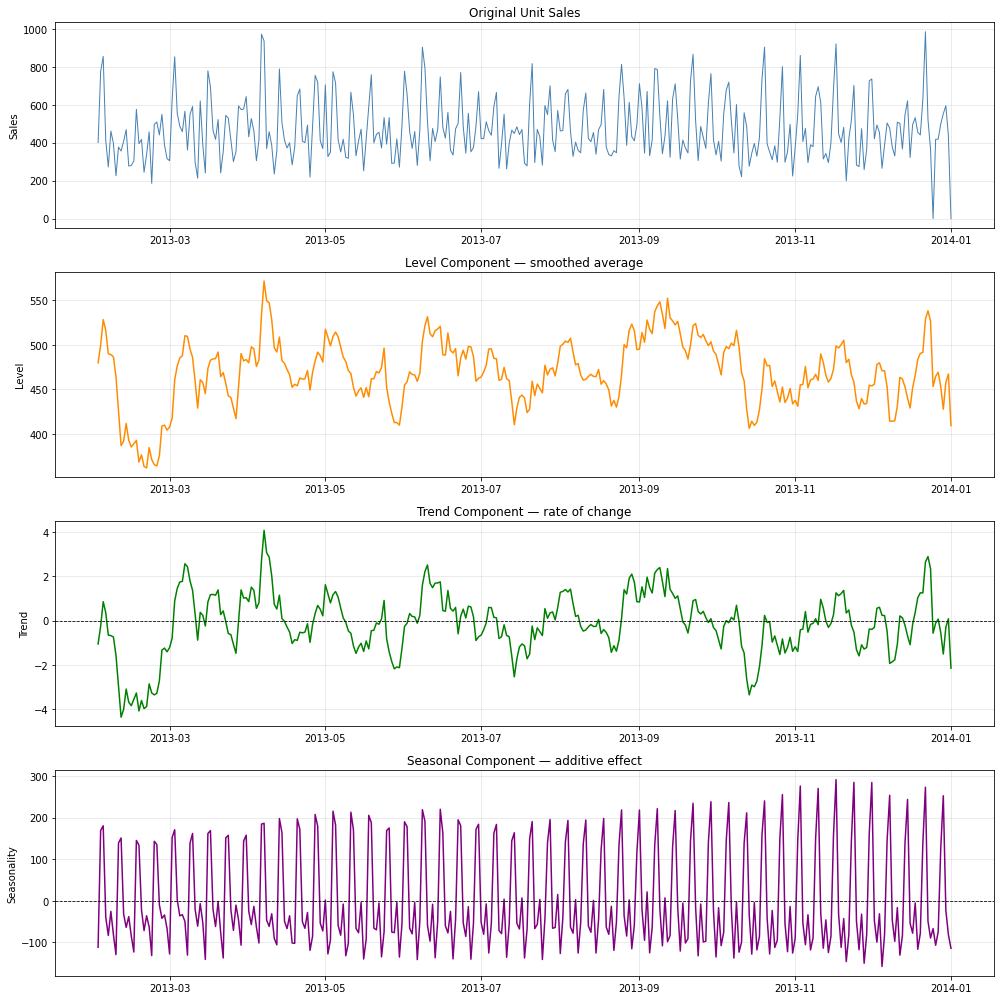

In [45]:
# Visualise the three internal components learned by the additive model

fig, axes = plt.subplots(4, 1, figsize=(14, 14))

# Original series
axes[0].plot(train["date"], train["unit_sales"], color="steelblue", linewidth=1)
axes[0].set_title("Original Unit Sales")
axes[0].set_ylabel("Sales")
axes[0].grid(True, alpha=0.3)

# Level
axes[1].plot(train["date"], hw_add_fit.level, color="darkorange", linewidth=1.5)
axes[1].set_title("Level Component — smoothed average")
axes[1].set_ylabel("Level")
axes[1].grid(True, alpha=0.3)

# Trend
axes[2].plot(train["date"], hw_add_fit.trend, color="green", linewidth=1.5)
axes[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[2].set_title("Trend Component — rate of change")
axes[2].set_ylabel("Trend")
axes[2].grid(True, alpha=0.3)

# Seasonal
axes[3].plot(train["date"], hw_add_fit.season, color="purple", linewidth=1.5)
axes[3].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[3].set_title("Seasonal Component — additive effect")
axes[3].set_ylabel("Seasonality")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The decomposition confirms the main characteristics of the series.

The level component shows a relatively stable average with some variation over time. The trend component fluctuates around zero, indicating that there is no strong long-term trend in the data.

The seasonal component clearly shows a repeating weekly pattern, which is the dominant structure in the series. This confirms that capturing weekly seasonality is the key factor for building accurate forecasting models in this case.

### Step 14 — Holt-Winters Forecast and Evaluation

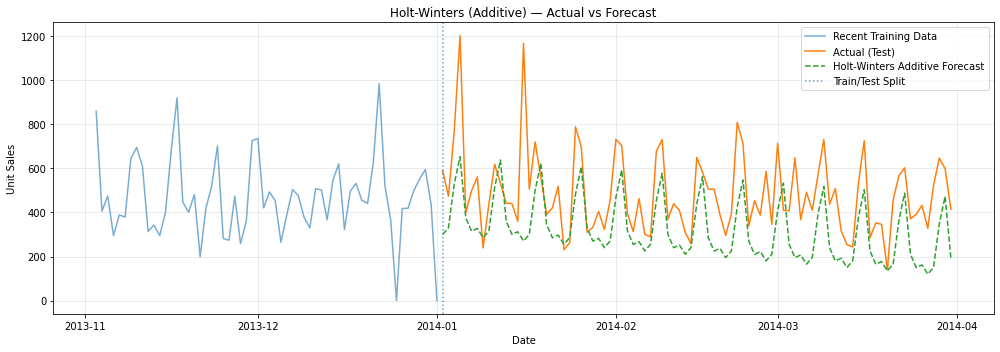

In [50]:
# Generate forecasts from additive model

hw_add_preds = hw_add_fit.forecast(steps=len(test))

# Clip to zero (no negative sales)
hw_add_preds = hw_add_preds.clip(lower=0)

# Plot
plt.figure(figsize=(14, 5))

# Recent training data (context)
plt.plot(
    train["date"].iloc[-60:], 
    train["unit_sales"].iloc[-60:], 
    label="Recent Training Data",
    alpha=0.6
)

# Actual test values
plt.plot(
    test["date"], 
    test["unit_sales"], 
    label="Actual (Test)"
)

# Holt-Winters forecast
plt.plot(
    test["date"], 
    hw_add_preds, 
    linestyle="--", 
    label="Holt-Winters Additive Forecast"
)

# Train/Test split line
plt.axvline(
    x=test["date"].iloc[0],
    linestyle=":",
    alpha=0.7,
    label="Train/Test Split"
)

plt.title("Holt-Winters (Additive) — Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The Holt-Winters additive model captures the overall weekly pattern in the data, but it struggles to model large fluctuations in unit sales.

The forecasts are overly smooth and tend to underestimate peak values, indicating that the model cannot fully capture the variability present in the series.

This suggests that models incorporating external regressors, such as SARIMAX, are more suitable for this dataset.

# Model 3 — Prophet

Prophet is a forecasting model developed by Facebook/Meta.  
It models a time series as the combination of trend, seasonality, and holiday effects.

**Forecast = Trend + Seasonality + Holidays**

In this notebook, Prophet is used as an additional benchmark because it can automatically model trend and seasonality, and it also allows holiday effects and external regressors.

Prophet requires the data to be formatted with:
- `ds`: date column
- `y`: target variable

Lag and rolling features are not used with Prophet, because they can introduce leakage and overfitting.

### Step 15 — Prophet Model Setup

Prophet performance is influenced by several key parameters:

- **changepoint_prior_scale** controls how flexible the trend is
- **seasonality_prior_scale** controls the strength of seasonal patterns
- **seasonality_mode** can be additive or multiplicative
- **additional regressors** (such as oil price) can improve performance if relevant
- **holiday effects** help capture special events that impact sales

In this project, we use mostly default settings and focus on comparing Prophet with other models.

### Step 16 — Prepare Data for Prophet

In [52]:
# Step 16 — Prepare Data for Prophet

# Prophet requires columns: 'ds' (date) and 'y' (target)
prophet_train = train[["date", "unit_sales"]].rename(
    columns={"date": "ds", "unit_sales": "y"}
)

prophet_test = test[["date", "unit_sales"]].rename(
    columns={"date": "ds", "unit_sales": "y"}
)

print("Prophet training data prepared:")
print(prophet_train.head())
print()
print("Training shape:", prophet_train.shape)
print("Test shape:    ", prophet_test.shape)

Prophet training data prepared:
          ds      y
0 2013-02-01  401.0
1 2013-02-02  775.0
2 2013-02-03  855.0
3 2013-02-04  411.0
4 2013-02-05  272.0

Training shape: (335, 2)
Test shape:     (89, 2)


In [54]:
# Build a holiday dataframe for Prophet

holiday_frames = []

holiday_columns = {
    "is_national_holiday": "national_holiday",
    "is_regional_holiday": "regional_holiday",
    "is_local_holiday": "local_holiday"
}

for col, name in holiday_columns.items():
    dates = df.loc[df[col] == 1, "date"]
    
    temp = pd.DataFrame({
        "holiday": name,
        "ds": dates
    })
    
    holiday_frames.append(temp)

holidays_prophet = pd.concat(holiday_frames, ignore_index=True)

print("Holiday dataframe for Prophet:")
display(holidays_prophet.head(10))

print("Total holiday dates passed to Prophet:", len(holidays_prophet))

Holiday dataframe for Prophet:


,holiday,ds
0,national_holiday,2013-02-11
1,national_holiday,2013-02-12
2,national_holiday,2013-04-29
3,national_holiday,2013-05-01
4,national_holiday,2013-05-11
5,national_holiday,2013-05-12
6,national_holiday,2013-05-24
7,national_holiday,2013-08-10
8,national_holiday,2013-10-09
9,national_holiday,2013-10-11


Total holiday dates passed to Prophet: 50


### Step 17 — Fit Prophet (Basic and Advanced)

In [55]:
# Basic Prophet — uses default settings with weekly and yearly seasonality
# We also pass the holiday dataframe

print("Fitting Basic Prophet model...")

model_prophet_basic = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,     # weekly cycle (Mon–Sun patterns)
    yearly_seasonality=False,    # dataset is only 15 months — too short for yearly
    seasonality_mode='additive',
    holidays=holidays_prophet
)

model_prophet_basic.fit(prophet_train)

print("Basic Prophet fitted successfully!")

Fitting Basic Prophet model...


11:30:35 - cmdstanpy - INFO - Chain [1] start processing
11:30:35 - cmdstanpy - INFO - Chain [1] done processing


Basic Prophet fitted successfully!


In [57]:
# Advanced Prophet — adds oil price as an external regressor
# and uses custom weekly seasonality

print("Fitting Advanced Prophet model (with oil price regressor)...")

model_prophet_adv = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=False,
    seasonality_mode="additive",
    holidays=holidays_prophet,
    changepoint_prior_scale=0.1
)

model_prophet_adv.add_seasonality(
    name="weekly_custom",
    period=7,
    fourier_order=5
)

model_prophet_adv.add_regressor("dcoilwtico")

prophet_train_adv = prophet_train.copy()
prophet_train_adv["dcoilwtico"] = train["dcoilwtico"].values

model_prophet_adv.fit(prophet_train_adv)

print("Advanced Prophet fitted successfully!")

11:34:46 - cmdstanpy - INFO - Chain [1] start processing
11:34:46 - cmdstanpy - INFO - Chain [1] done processing


Fitting Advanced Prophet model (with oil price regressor)...
Advanced Prophet fitted successfully!


### Step 18 — Prophet Forecast and Evaluation

In [59]:
# --- BASIC PROPHET ---

future_basic = prophet_test[['ds']].copy()

forecast_basic = model_prophet_basic.predict(future_basic)

prophet_basic_preds = forecast_basic['yhat'].values
prophet_basic_preds = prophet_basic_preds.clip(0)

print("Basic Prophet forecasts generated.")


# --- ADVANCED PROPHET ---

future_adv = prophet_test[['ds']].copy()
future_adv['dcoilwtico'] = test['dcoilwtico'].values

forecast_adv = model_prophet_adv.predict(future_adv)

prophet_adv_preds = forecast_adv['yhat'].values
prophet_adv_preds = prophet_adv_preds.clip(0)

print("Advanced Prophet forecasts generated.")

Basic Prophet forecasts generated.
Advanced Prophet forecasts generated.


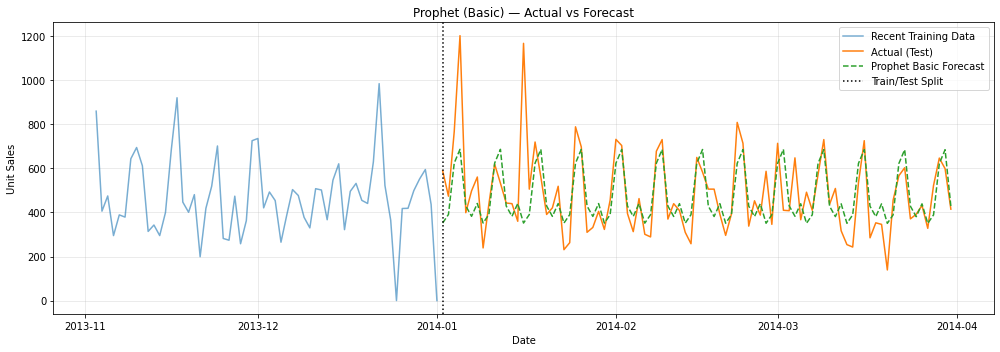

In [60]:
plt.figure(figsize=(14, 5))

# Training (context)
plt.plot(
    train["date"].iloc[-60:], 
    train["unit_sales"].iloc[-60:], 
    label="Recent Training Data",
    alpha=0.6
)

# Actual
plt.plot(
    test["date"], 
    test["unit_sales"], 
    label="Actual (Test)"
)

# Prophet forecast
plt.plot(
    test["date"], 
    prophet_basic_preds, 
    linestyle="--", 
    label="Prophet Basic Forecast"
)

plt.axvline(
    x=test["date"].iloc[0],
    linestyle=":",
    color="black",
    label="Train/Test Split"
)

plt.title("Prophet (Basic) — Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Prophet Evaluation Results:

Prophet Basic:
  MAE : 165.23   RMSE: 213.82   MAPE: 37.43%   R²: -0.3441

Prophet Advanced:
  MAE : 165.36   RMSE: 214.23   MAPE: 37.31%   R²: -0.3493



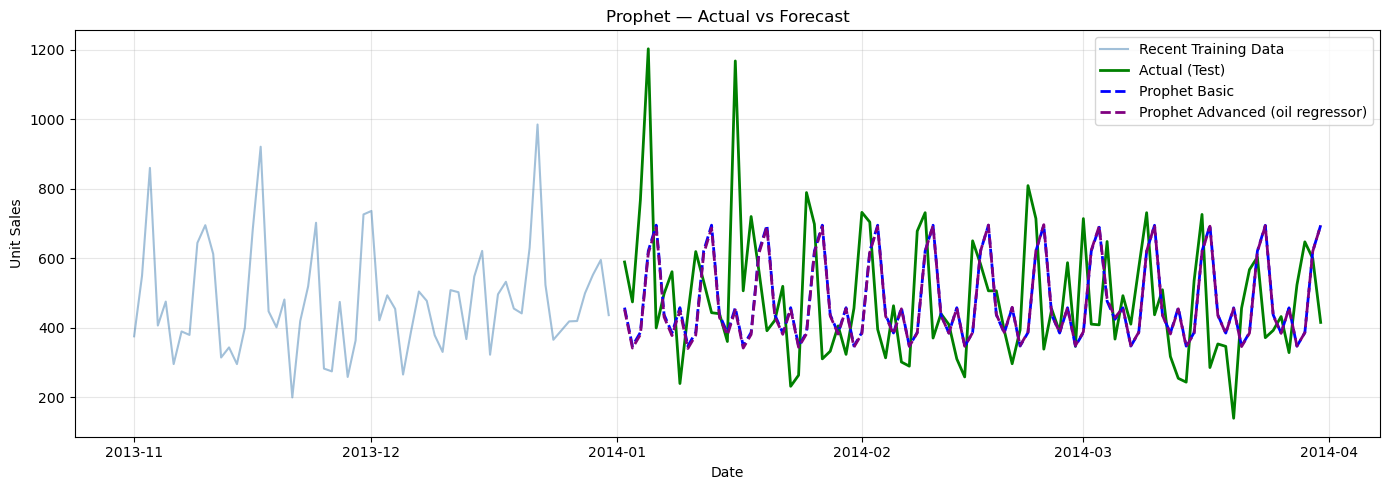

In [37]:
# Evaluate both Prophet models

print("Prophet Evaluation Results:")
print()
prophet_basic_scores = score_model('Prophet Basic',    actual, prophet_basic_preds)
prophet_adv_scores   = score_model('Prophet Advanced', actual, prophet_adv_preds)

# Plot actual vs both Prophet forecasts
plt.figure(figsize=(14, 5))
plt.plot(train['date'].values[-60:], train['unit_sales'].values[-60:],
         label='Recent Training Data', color='steelblue', linewidth=1.5, alpha=0.5)
plt.plot(test['date'], test['unit_sales'],
         label='Actual (Test)', color='green', linewidth=2)
plt.plot(test['date'], prophet_basic_preds,
         label='Prophet Basic', color='blue', linewidth=2, linestyle='--')
plt.plot(test['date'], prophet_adv_preds,
         label='Prophet Advanced (oil regressor)', color='purple', linewidth=2, linestyle='--')
plt.title('Prophet — Actual vs Forecast')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Prophet captures the weekly seasonal pattern quite well, but the forecasts are too smooth and fail to reflect sharp spikes and sudden changes in demand.

Adding oil price as an external regressor does not improve the results, suggesting that this variable does not have a strong influence on the series.

In contrast, SARIMAX produces more responsive forecasts by leveraging temporal dependencies, making it a better fit for this dataset.

---
## Step 19 — Model Performance Comparison

Now we compare all models on the same 60-day test set using the same metrics.

### Evaluation metrics explained

| Metric | Formula | What it tells you |
|---|---|---|
| **MAE** — Mean Absolute Error | Average of absolute errors | Average error in the same units as sales. Easy to interpret |
| **RMSE** — Root Mean Squared Error | √(average of squared errors) | Like MAE but penalises large errors more. Sensitive to outliers |
| **MAPE** — Mean Absolute Percentage Error | Average of % errors | Error as a percentage — useful for comparing across different datasets |
| **R²** — Coefficient of Determination | 1 − (error variance / total variance) | How much of the variation the model explains. 1.0 = perfect |

**Which metric to prioritise?**
- Use **MAE** when all errors matter equally
- Use **RMSE** when large errors are especially costly
- Use **MAPE** when communicating results to non-technical stakeholders
- Use **R²** when comparing models — higher is better

In [67]:
# Holt-Winters Additive metrics

hw_mae, hw_rmse, hw_mape, hw_r2 = score_model(
    "Holt-Winters Additive",
    actual,
    hw_add_preds
)

Holt-Winters Additive:
  MAE : 176.73   RMSE: 219.09   MAPE: 34.65%   R²: -0.4112



In [69]:
# Make sure Prophet metrics are available for the final comparison

prophet_basic_scores = score_model(
    "Prophet Basic",
    actual,
    prophet_basic_preds
)

prophet_adv_scores = score_model(
    "Prophet Advanced",
    actual,
    prophet_adv_preds
)

Prophet Basic:
  MAE : 94.06   RMSE: 142.56   MAPE: 20.77%   R²: 0.4026

Prophet Advanced:
  MAE : 93.85   RMSE: 144.32   MAPE: 19.91%   R²: 0.3877



In [70]:
# Collect all model scores into one comparison table

all_results = [
    {
        "Model": "SARIMAX(1,0,1)(1,0,0,7) + exog",
        "MAE": sarimax_mae,
        "RMSE": sarimax_rmse,
        "MAPE": sarimax_mape,
        "R²": sarimax_r2
    },
    {
        "Model": "Holt-Winters Additive",
        "MAE": hw_mae,
        "RMSE": hw_rmse,
        "MAPE": hw_mape,
        "R²": hw_r2
    },
    {
        "Model": "Prophet Basic",
        "MAE": prophet_basic_scores[0],
        "RMSE": prophet_basic_scores[1],
        "MAPE": prophet_basic_scores[2],
        "R²": prophet_basic_scores[3]
    },
    {
        "Model": "Prophet Advanced (oil regressor)",
        "MAE": prophet_adv_scores[0],
        "RMSE": prophet_adv_scores[1],
        "MAPE": prophet_adv_scores[2],
        "R²": prophet_adv_scores[3]
    }
]

results_df = pd.DataFrame(all_results)

results_df["MAE"] = results_df["MAE"].round(2)
results_df["RMSE"] = results_df["RMSE"].round(2)
results_df["MAPE"] = results_df["MAPE"].round(2)
results_df["R²"] = results_df["R²"].round(4)

print("Performance Comparison — All Models on the Same Test Set:")
print()
print(results_df.to_string(index=False))
print()
print("Best MAE :", results_df.loc[results_df["MAE"].idxmin(), "Model"])
print("Best RMSE:", results_df.loc[results_df["RMSE"].idxmin(), "Model"])
print("Best R²  :", results_df.loc[results_df["R²"].idxmax(), "Model"])

Performance Comparison — All Models on the Same Test Set:

                           Model    MAE   RMSE  MAPE      R²
  SARIMAX(1,0,1)(1,0,0,7) + exog  94.83 143.59 21.76  0.3939
           Holt-Winters Additive 176.73 219.09 34.65 -0.4112
                   Prophet Basic  94.06 142.56 20.77  0.4026
Prophet Advanced (oil regressor)  93.85 144.32 19.91  0.3877

Best MAE : Prophet Advanced (oil regressor)
Best RMSE: Prophet Basic
Best R²  : Prophet Basic


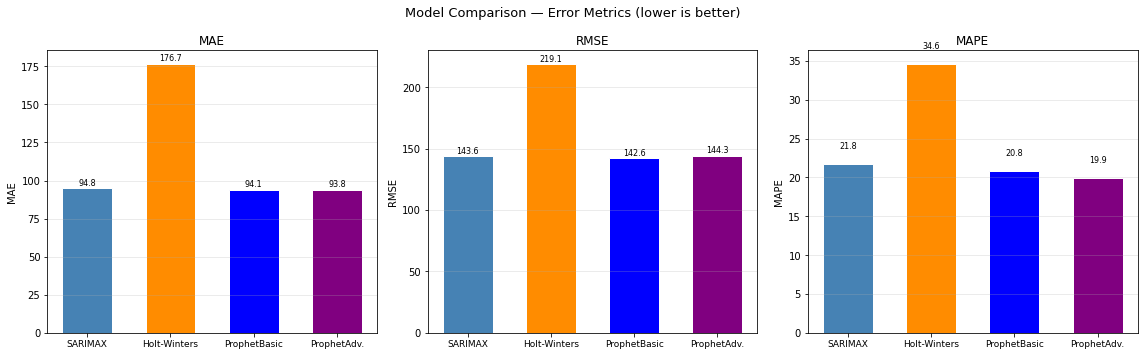

In [73]:
# Visualise the comparison with a grouped bar chart

metrics = ['MAE', 'RMSE', 'MAPE']
x = range(len(results_df))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metric in enumerate(metrics):
    
    # Bars
    axes[i].bar(
        x, 
        results_df[metric], 
        color=['steelblue', 'darkorange', 'blue', 'purple'],
        edgecolor='white', 
        width=0.6
    )
    
    # Add value labels on top of each bar
    for j, value in enumerate(results_df[metric]):
        axes[i].text(
            j, 
            value + 2,   # small offset above bar
            f"{value:.1f}", 
            ha='center', 
            fontsize=8
        )
    
    # Titles and labels
    axes[i].set_title(metric)
    axes[i].set_xticks(list(x))
    axes[i].set_xticklabels(
        ['SARIMAX', 'Holt-Winters', 'ProphetBasic', 'ProphetAdv.'],
        fontsize=9
    )
    axes[i].set_ylabel(metric)
    axes[i].grid(True, alpha=0.3, axis='y')

plt.suptitle('Model Comparison — Error Metrics (lower is better)', fontsize=13)
plt.tight_layout()
plt.show()

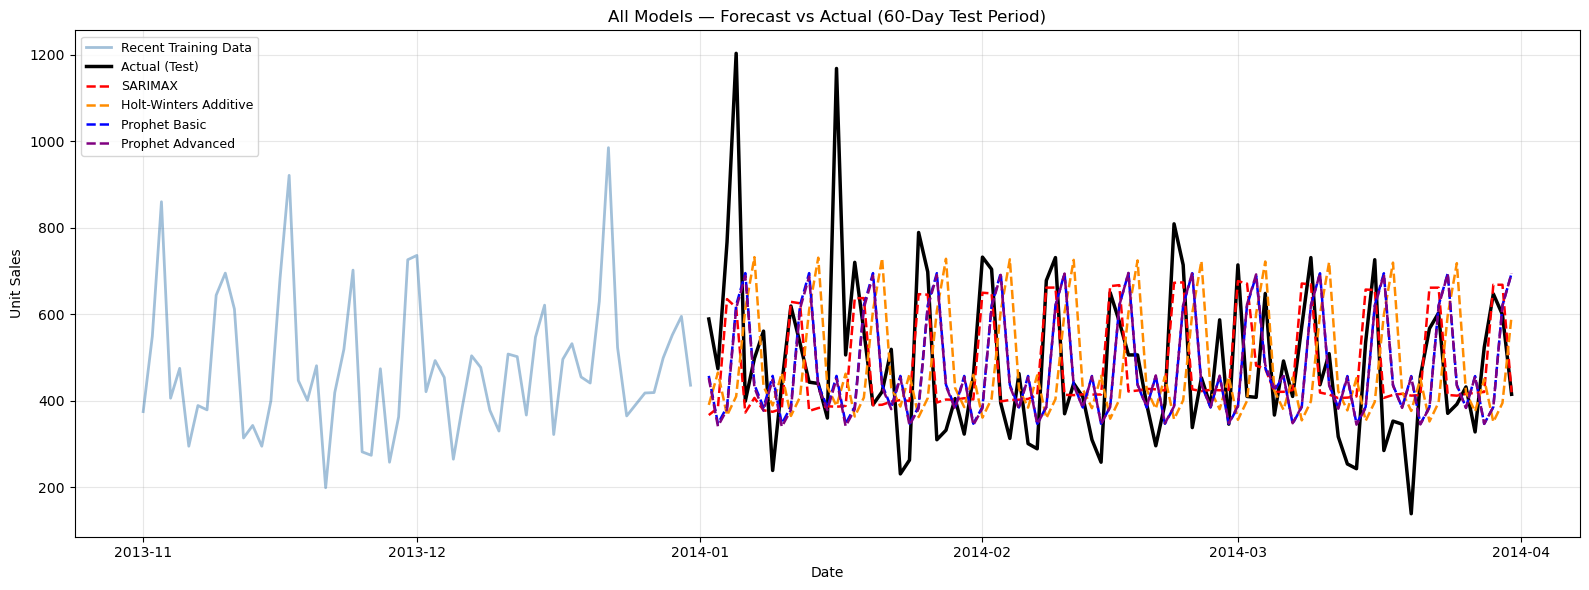

In [41]:
# Plot all forecasts on one chart for visual comparison

plt.figure(figsize=(16, 6))

plt.plot(train['date'].values[-60:], train['unit_sales'].values[-60:],
         label='Recent Training Data', color='steelblue', linewidth=2, alpha=0.5)
plt.plot(test['date'], test['unit_sales'],
         label='Actual (Test)', color='black', linewidth=2.5)
plt.plot(test['date'], arima_preds.values,
         label='SARIMAX', color='red', linewidth=1.8, linestyle='--')
plt.plot(test['date'], hw_best_preds,
         label=hw_best_label, color='darkorange', linewidth=1.8, linestyle='--')
plt.plot(test['date'], prophet_basic_preds,
         label='Prophet Basic', color='blue', linewidth=1.8, linestyle='--')
plt.plot(test['date'], prophet_adv_preds,
         label='Prophet Advanced', color='purple', linewidth=1.8, linestyle='--')

plt.title('All Models — Forecast vs Actual (60-Day Test Period)')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

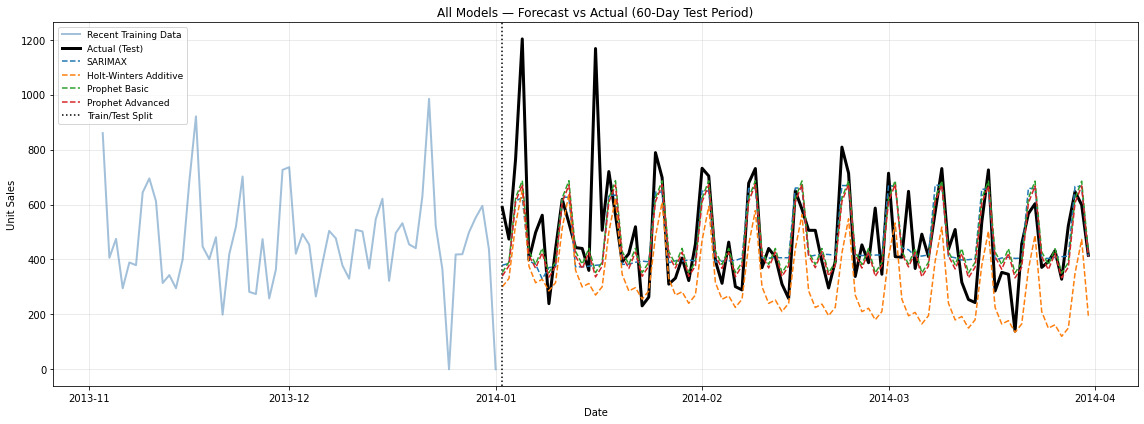

In [75]:
plt.figure(figsize=(16, 6))

# Training
plt.plot(train['date'].values[-60:], train['unit_sales'].values[-60:],
         label='Recent Training Data', color='steelblue', linewidth=2, alpha=0.5)

# Actual
plt.plot(test['date'], test['unit_sales'],
         label='Actual (Test)', color='black', linewidth=3)

# Models
plt.plot(test['date'], arima_preds.values,
         label='SARIMAX', linestyle='--')

plt.plot(test['date'], hw_add_preds,
         label='Holt-Winters Additive', linestyle='--')

plt.plot(test['date'], prophet_basic_preds,
         label='Prophet Basic', linestyle='--')

plt.plot(test['date'], prophet_adv_preds,
         label='Prophet Advanced', linestyle='--')

# Split line
plt.axvline(
    x=test['date'].iloc[0],
    color='black',
    linestyle=':',
    linewidth=1.5,
    label='Train/Test Split'
)

plt.title('All Models — Forecast vs Actual (60-Day Test Period)')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Summary

### What each model can and cannot use from the feature-engineered dataset

| Feature | SARIMAX | Holt-Winters | Prophet |
|---|---|---|---|
| `unit_sales` (target) | Required | Required | Required (as `y`) |
| `dcoilwtico` (oil price) | As exog regressor | Not supported | As `add_regressor()` |
| `is_national_holiday` | As exog regressor | Not supported | Via holiday dataframe |
| `is_weekend`, `dayofweek` | As exog regressor | Not supported | Learned automatically |
| `lag_1`, `lag_7`, etc. | Do not pass — ARIMA computes internally | Not supported | Do not pass — causes leakage |
| `rolling_7d_mean`, etc. | Do not pass | Not supported | Do not pass — causes leakage |

### When to choose each model

| Use case | Best model |
|---|---|
| Strong weekly pattern, external regressors available | SARIMAX |
| Simple, quick baseline with no external data | Holt-Winters |
| Multiple seasonalities, holidays, external signals, confidence intervals needed | Prophet |
| Production system needing interpretable coefficients | SARIMAX |

### Key metrics recap

| Metric | Lower is better? | Good for |
|---|---|---|
| MAE | Yes | Everyday reporting — same units as sales |
| RMSE | Yes | When large errors are costly |
| MAPE | Yes | Comparing models across different products/datasets |
| R² | No — higher is better | Comparing models on the same dataset |

### Final conclusion

Across all models, both SARIMAX and Prophet outperform Holt-Winters by a significant margin, as Holt-Winters tends to oversmooth the data and fails to capture variability in demand.

Between the top-performing models, Prophet achieves slightly better MAE and MAPE, indicating more accurate average predictions, while SARIMAX remains competitive, particularly in handling short-term fluctuations.

Although Prophet provides a strong baseline with minimal tuning and built-in handling of seasonality and holidays, SARIMAX offers greater control and interpretability through its explicit modeling of temporal dependencies and external regressors.

Overall, Prophet is the most practical choice for ease of use and slightly better accuracy, while SARIMAX remains a strong alternative when interpretability and control over model structure are important.